In [2]:
import pennylane as qml
import numpy as np

In [121]:
# Build a device
# Size of the Sudoku:
size = 2
# need ceil(log2(size)) qubits per grid, and 3 ancilla so...
m = int(2**(np.log2(size)-1)*size**2)
n = m + 5
print(n)
dev = qml.device("default.qubit",n)

9


In [122]:
# Transfer a Sudoku setup to initial states
def process_initial_state(sudoku):
    for i,row in enumerate(sudoku):
        for j,item in enumerate(row):
            if item == 0:
                pass
            elif item == 1:
                qml.X(i*size+j)
            else:
                qml.H(i*size+j)
                

In [123]:
# Grover iteration
def grover_iteration(sudoku):
    # check_rows(size)
    # check_cols(size)
    # check_boxes()
    # qml.MultiControlledX([i+1 for i in range(m)]+[n])
    checks()
    diffusion(m,sudoku)

In [124]:
# Sudoku constraints
# def check_rows(size,last_result,ancilla):
#     for i in range(size):
#         for j in range(size):
#             qml.CX([i*size+j+1,ancilla])
def checks():
    qml.CNOT([0,4])
    qml.CNOT([1,4])
    #===============
    qml.CNOT([2,5])
    qml.CNOT([3,5])
    #===============
    qml.CNOT([0,6])
    qml.CNOT([2,6])
    #===============
    qml.CNOT([1,7])
    qml.CNOT([3,7])
    # update result
    qml.MultiControlledX([4,5,6,7,8])
    qml.CNOT([3,7])
    qml.CNOT([1,7])
    qml.CNOT([2,6])
    qml.CNOT([0,6])
    qml.CNOT([3,5])
    qml.CNOT([2,5])
    qml.CNOT([1,4])
    qml.CNOT([0,4])
    
    
            

In [130]:
def diffusion(size,sudoku):
    sudoku = [item for sublist in sudoku for item in sublist]
    for i in range(size):
        if sudoku[i]==2:
            qml.H(i)
    qml.MultiControlledX([i for i, val in enumerate(sudoku) if val == 2]+[n-1], control_values = [0 for i in sudoku if i==2])
    for i in range(size):
        if sudoku[i]==2:
            qml.H(i)

In [135]:
@qml.qnode(dev)
def sudoku_circuit(sudoku):
    process_initial_state(sudoku)
    qml.X(n-1)
    qml.H(n-1)
    grover_iteration(sudoku)
    qml.H(n-1)
    qml.X(n-1)
    return qml.probs([0,1,2,3])

In [136]:
print(qml.draw(sudoku_circuit)([[0,2],[2,2]]))

0: ────╭●──────────╭●──────────────────────╭●──────────╭●─────────────┤ ╭Probs
1: ──H─│──╭●───────│─────╭●──────────╭●────│────────╭●─│───H─╭○──H────┤ ├Probs
2: ──H─│──│──╭●────│──╭●─│───────────│──╭●─│─────╭●─│──│───H─├○──H────┤ ├Probs
3: ──H─│──│──│──╭●─│──│──│──╭●────╭●─│──│──│──╭●─│──│──│───H─├○──H────┤ ╰Probs
4: ────╰X─╰X─│──│──│──│──│──│──╭●─│──│──│──│──│──│──╰X─╰X────│────────┤       
5: ──────────╰X─╰X─│──│──│──│──├●─│──│──│──│──╰X─╰X──────────│────────┤       
6: ────────────────╰X─╰X─│──│──├●─│──│──╰X─╰X────────────────│────────┤       
7: ──────────────────────╰X─╰X─├●─╰X─╰X──────────────────────│────────┤       
8: ──X──H──────────────────────╰X────────────────────────────╰X──H──X─┤       


In [137]:
result = sudoku_circuit([[0,2],[2,2]])
print(result)
results = qml.snapshots(sudoku_circuit)([[0,2],[2,2]])
print(results)

[0.03125 0.03125 0.03125 0.03125 0.03125 0.03125 0.78125 0.03125 0.
 0.      0.      0.      0.      0.      0.      0.     ]
{'execution_results': array([0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.78125,
       0.03125, 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     ])}


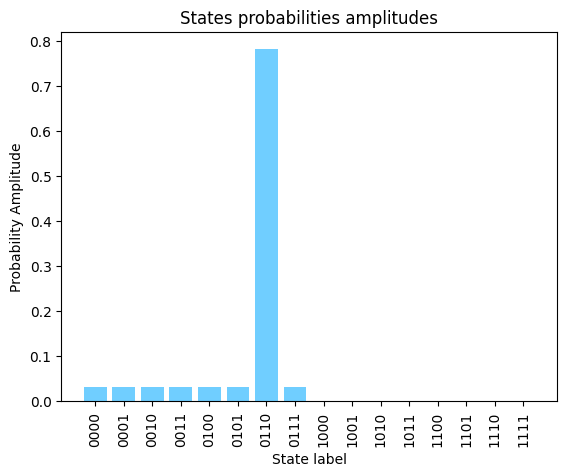

In [138]:
import matplotlib.pyplot as plt
y = np.real(results["execution_results"])
bit_strings = [f"{x:0{4}b}" for x in range(len(y))]

plt.bar(bit_strings, y, color = "#70CEFF")

plt.xticks(rotation="vertical")
plt.xlabel("State label")
plt.ylabel("Probability Amplitude")
plt.title("States probabilities amplitudes")
plt.show()

{'execution_results': array([0.25, 0.25, 0.25, 0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  ])}


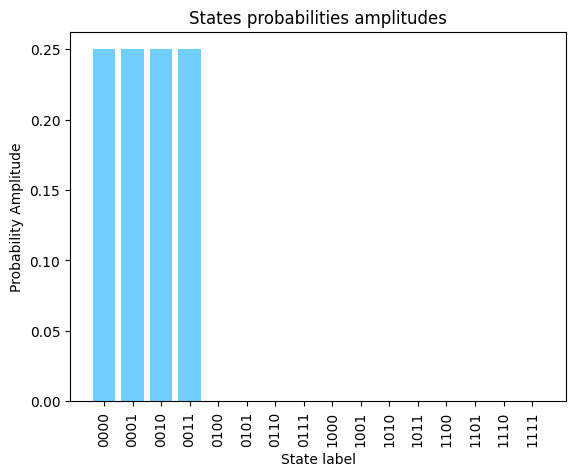

In [139]:
results = qml.snapshots(sudoku_circuit)([[0,0],[2,2]])
print(results)
y = np.real(results["execution_results"])
bit_strings = [f"{x:0{4}b}" for x in range(len(y))]

plt.bar(bit_strings, y, color = "#70CEFF")

plt.xticks(rotation="vertical")
plt.xlabel("State label")
plt.ylabel("Probability Amplitude")
plt.title("States probabilities amplitudes")
plt.show()

{'execution_results': array([0.015625, 0.015625, 0.015625, 0.015625, 0.015625, 0.015625,
       0.390625, 0.015625, 0.015625, 0.390625, 0.015625, 0.015625,
       0.015625, 0.015625, 0.015625, 0.015625])}


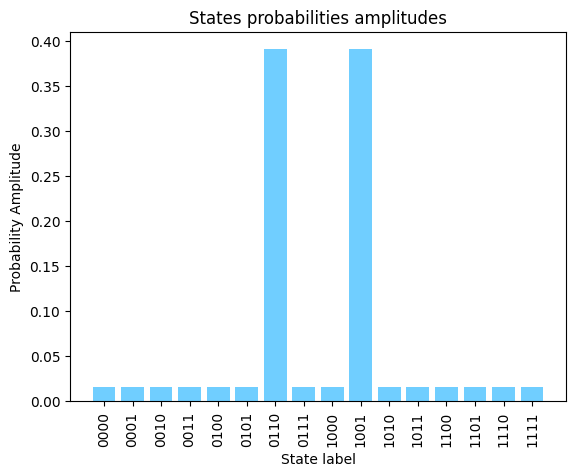

In [140]:
results = qml.snapshots(sudoku_circuit)([[2,2],[2,2]])
print(results)
y = np.real(results["execution_results"])
bit_strings = [f"{x:0{4}b}" for x in range(len(y))]

plt.bar(bit_strings, y, color = "#70CEFF")

plt.xticks(rotation="vertical")
plt.xlabel("State label")
plt.ylabel("Probability Amplitude")
plt.title("States probabilities amplitudes")
plt.show()